In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df = df.drop(columns=['Product Description'])
df['Order Zipcode'] = df['Order Zipcode'].fillna('UNKNOWN')
df['Customer Lname'] = df['Customer Lname'].fillna('UNKNOWN')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

print(df.shape)

(180519, 52)


In [2]:
model_df = df.copy()

model_df['order_month'] = model_df['order date (DateOrders)'].dt.month
model_df['order_weekday'] = model_df['order date (DateOrders)'].dt.dayofweek

features = ['Shipping Mode', 'Order Region', 'Market', 'Category Name',
            'Order Item Discount Rate', 'Order Item Quantity',
            'order_month', 'order_weekday']
target = 'Late_delivery_risk'

X = model_df[features].copy()
y = model_df[target].copy()

categorical_cols = ['Shipping Mode', 'Order Region', 'Market', 'Category Name']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)
X.head()

(180519, 82)


,Order Item Discount Rate,Order Item Quantity,order_month,order_weekday,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class,Order Region_Caribbean,Order Region_Central Africa,Order Region_Central America,...,Category Name_Sporting Goods,Category Name_Strength Training,Category Name_Tennis & Racquet,Category Name_Toys,Category Name_Trade-In,Category Name_Video Games,Category Name_Water Sports,Category Name_Women's Apparel,Category Name_Women's Clothing,Category Name_Women's Golf Clubs
0,0.04,1,1,2,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,0.05,1,1,5,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,0.06,1,1,5,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,0.07,1,1,5,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,0.09,1,1,5,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(144415, 82) (36104, 82)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104

ROC-AUC: 0.729592169724023


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.62      0.83      0.71     16308
           1       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.71      0.69     36104
weighted avg       0.72      0.69      0.69     36104

ROC-AUC: 0.7347559591522517


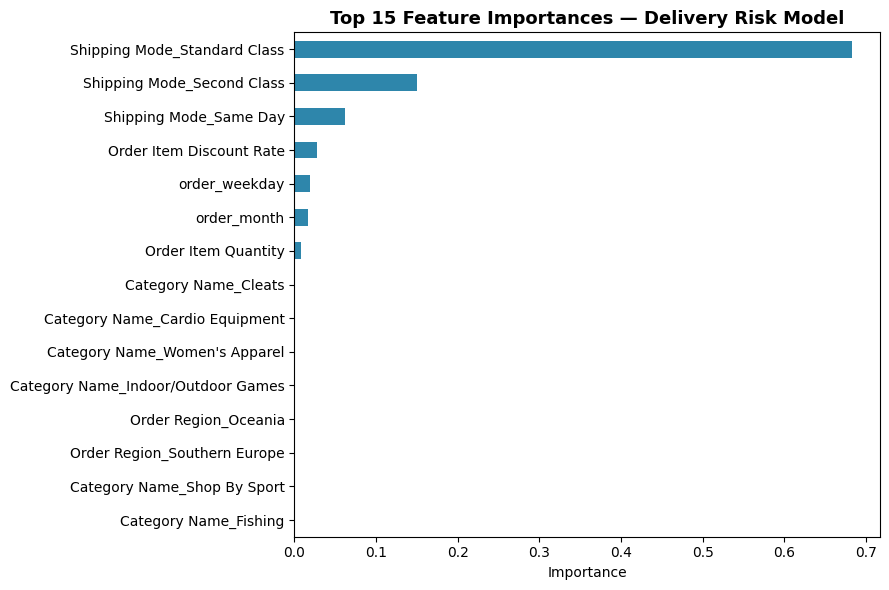

In [6]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='#2E86AB')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Delivery Risk Model', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../docs/screenshots/feature_importance.png')
plt.show()

In [7]:
rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1,
    class_weight='balanced'
)
rf_weighted.fit(X_train, y_train)

y_pred_rfw = rf_weighted.predict(X_test)
y_proba_rfw = rf_weighted.predict_proba(X_test)[:, 1]

print("=== Random Forest (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_rfw))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rfw))

=== Random Forest (class_weight='balanced') ===
              precision    recall  f1-score   support

           0       0.62      0.86      0.72     16308
           1       0.83      0.57      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.70     36104
weighted avg       0.74      0.70      0.70     36104

ROC-AUC: 0.7347209457115014
